In [327]:
# Imports

get_ipython().system('pip install stargazer --force-reinstall')

import pandas as pd
import numpy as np
import re
from IPython.display import HTML
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
from stargazer.stargazer import Stargazer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

  Using cached stargazer-0.0.7-py3-none-any.whl.metadata (6.3 kB)
Using cached stargazer-0.0.7-py3-none-any.whl (15 kB)
  Attempting uninstall: stargazer
    Found existing installation: stargazer 0.0.7
    Uninstalling stargazer-0.0.7:
      Successfully uninstalled stargazer-0.0.7


In [328]:
# Creating dataframes

df_cats = pd.read_csv('D:\\College_Stuff\\Praca_licencjacka\\cats_analysis.csv')
df_dogs = pd.read_csv('D:\\College_Stuff\\Praca_licencjacka\\dogs_analysis.csv')

In [329]:
newest_released = df_cats['released'].max()

print(f"The newest available released date is: {newest_released}")

The newest available released date is: 2025-03-26


In [330]:
# Admitted and Released correction

def correct_date_columns(df):

    df['released'] = pd.to_datetime(df['released'])
    df['admitted'] = pd.to_datetime(df['admitted'])

    incorrect_mask = df['admitted'] > df['released']

    num_corrections = incorrect_mask.sum()

    if num_corrections > 0:
        print(f"Correcting {num_corrections} rows with incorrect date order")

        temp = df.loc[incorrect_mask, 'admitted'].copy()
        df.loc[incorrect_mask, 'admitted'] = df.loc[incorrect_mask, 'released']
        df.loc[incorrect_mask, 'released'] = temp

    else:
        print("All date columns are already in correct order")

    return df

df_cats = correct_date_columns(df_cats)
df_dogs = correct_date_columns(df_dogs)

Correcting 129 rows with incorrect date order
Correcting 14 rows with incorrect date order


In [331]:
# Admitted month

def get_month(df, date_column='admitted'):

    df[date_column] = pd.to_datetime(df[date_column])

    df['month'] = df[date_column].dt.month_name()

    return df

df_cats = get_month(df_cats)
df_dogs = get_month(df_dogs)

In [332]:
# Released month

def get_month_r(df, date_column='released'):

    df[date_column] = pd.to_datetime(df[date_column])

    df['month_r'] = df[date_column].dt.month_name()

    return df

df_cats = get_month_r(df_cats)

In [333]:
# Age conversion

def clean_age_column(df, age_column_name):

    def age_converter(age_str):
        if pd.isna(age_str):
            return np.nan

        age_str = str(age_str).lower()

        numbers = re.findall(r'\d+', age_str)
        if not numbers:
            return np.nan

        age_val = int(numbers[0])

        if any(word in age_str for word in ['miesiąc', 'miesiące', 'miesięcy']):
            return age_val
        elif any(word in age_str for word in ['rok', 'lat', 'lata']):
            return age_val * 12
        else:
            return np.nan

    df['age_months'] = df[age_column_name].apply(age_converter).astype('Int64')
    df['age_years'] = (df['age_months'] / 12).round(2)

    return df

df_cats = clean_age_column(df_cats, 'age')
df_dogs = clean_age_column(df_dogs, 'age')

In [334]:
# Age approximation / correction

reference_date = pd.to_datetime('2025-03-15')

def approximate_age_calculation(row, ref_date):
    release_date = pd.to_datetime(row['admitted'])
    delta = ref_date - release_date
    months_elapsed = delta.days / 30.44 - 1
    approximate_age_admitted = float(row['age_months']) - months_elapsed
    return max(0, approximate_age_admitted)

df_cats['age_admitted'] = np.floor(df_cats.apply(approximate_age_calculation, args=(reference_date,), axis=1)).astype(int)
df_dogs['age_admitted'] = np.floor(df_dogs.apply(approximate_age_calculation, args=(reference_date,), axis=1)).astype(int)

In [335]:
# Checking rough quality of age approximation via manual review based on descriptions
# Not all cats had age stated in description, so during process the random_state was changed several times

'''
age_test = df_cats[df_cats['age_admitted'] > 0]
#age_test = df_dogs[df_dogs['age_admitted'] > 0]

if len(age_test) > 0:
    random_sample = age_test.sample(n=min(10, len(age_test)), random_state = 13)
    print(random_sample[['species_id', 'age_months', 'age_admitted', 'admitted', 'breed', 'url']].to_string(index=False))
else:
    print("No entries found")
'''

'\nage_test = df_cats[df_cats[\'age_admitted\'] > 0]\n#age_test = df_dogs[df_dogs[\'age_admitted\'] > 0]\n\nif len(age_test) > 0:\n    random_sample = age_test.sample(n=min(10, len(age_test)), random_state = 13)\n    print(random_sample[[\'species_id\', \'age_months\', \'age_admitted\', \'admitted\', \'breed\', \'url\']].to_string(index=False))\nelse:\n    print("No entries found")\n'

In [336]:
# Age grouping

def age_groups(age_admitted):

    if age_admitted <= 12:
        return 'young'
    elif age_admitted <= 84:  # 7 years
        return 'adult'
    else:
        return 'senior'

df_cats['age_group'] = df_cats['age_admitted'].apply(age_groups)
df_dogs['age_group'] = df_dogs['age_admitted'].apply(age_groups)

In [337]:
# Weight conversion

def clean_weight_column(df, weight_column='weight'):

    df['weight'] = (
        df['weight']
        .astype(str)
        .str.lower()
        .str.replace('kg', '', regex=False)
        .str.strip()
        .str.replace(',', '.')
        .astype(float)
    )
    return df

df_cats = clean_weight_column(df_cats, 'weight')
df_dogs = clean_weight_column(df_dogs, 'weight')

In [338]:
# Stay length

df_cats['stay_length'] = ((pd.to_datetime(df_cats['released']) - pd.to_datetime(df_cats['admitted'])).dt.days).astype('Int64')
df_dogs['stay_length'] = ((pd.to_datetime(df_dogs['released']) - pd.to_datetime(df_dogs['admitted'])).dt.days).astype('Int64')

In [339]:
# Division points

p75_cats = df_cats['stay_length'].quantile(0.75)
p75_dogs = df_dogs['stay_length'].quantile(0.75)
print(f"Cat 75th percentile: {p75_cats:.1f} days")
print(f"Dog 75th percentile: {p75_dogs:.1f} days")

Cat 75th percentile: 43.0 days
Dog 75th percentile: 172.0 days


In [340]:
# Gender to binary

def gender_binary(df, gender_column='gender'):
    df = df.copy()
    df[gender_column] = df[gender_column].astype(str).str.lower().str.strip()
    df[gender_column] = df[gender_column].replace({
        'samica': True,
        'samiec': False
    })
    df[gender_column] = df[gender_column].astype('bool')
    return df

df_cats = gender_binary(df_cats)
df_dogs = gender_binary(df_dogs)

In [341]:
# Dog breed grouping

def breed_groups(df, breed_column='breed', new_column='breed_group', patterns=None):
    
    df = df.copy()

    df[breed_column] = df[breed_column].fillna('Mieszaniec')
    
    breeds = (
        df[breed_column]
        .astype(str)
        .str.lower()
        .str.replace(r'^mix\s+', '', regex=True)
        .str.strip()
    )
    
    if patterns is None:
        patterns = {
            'buld': 'Buldog',
            'terrier': 'Terrier',
            'terier': 'Terrier',
            'mastif': 'Mastif',
            'sznaucer': 'Sznaucer',
            'wyżeł': 'Wyżeł',
            'szpic': 'Szpic',
            'chart': 'Chart',
            'pudel': 'Pudel',
            'biszon': 'Biszon',
            'cane': 'Cane Corso',
            'cocker spaniel': 'Cocker Spaniel',
            'pinczer': 'Pinczer',
            'w typie': 'Mieszaniec',
            'doberm': 'Doberman',
            'amstaf': 'Amstaff',
            'łajka': 'Łajka'
            
        }
    
    df[new_column] = df[breed_column]
    
    for pattern, group_name in patterns.items():
        df.loc[breeds.str.contains(pattern, na=False), new_column] = group_name
    
    return df

df_dogs = breed_groups(df_dogs)

In [342]:
# Breed mapping

def breed_mapping(df, breed_column='breed', new_column='breed_id'):

    df = df.copy()
    
    df[breed_column] = df[breed_column].str.lower().str.strip()
    
    unique_breeds = sorted(df[breed_column].unique())
    breed_mapping = {breed: idx + 1 for idx, breed in enumerate(unique_breeds)}
    
    df[new_column] = df[breed_column].map(breed_mapping)


    print("Breed mapping:")
    for breed, breed_id in breed_mapping.items():
        print(f"{breed} - {breed_id}")
    print("\n")

    
    return df

df_cats = breed_mapping(df_cats)
df_dogs = breed_mapping(df_dogs, 'breed_group')

Breed mapping:
abisyński - 1
brytyjski - 2
burmański - 3
chausie - 4
dalekowschodni - 5
devon rex - 6
egzotyk - 7
europejska - 8
maine coon - 9
mieszaniec - 10
mix półdłu - 11
mix ragdol - 12
norweski leśny - 13
orientalny - 14
perski - 15
ragdoll - 16
rosyjski niebieski - 17
sfinks - 18
snowshoe - 19
syberyjski - 20
syjamski - 21
szkocki kr - 22
szkocki zwisłouchy - 23
tonkijski - 24


Breed mapping:
akita inu - 1
amstaff - 2
anatolian - 3
beagle - 4
bernardyn - 5
berneński pies pasterski - 6
biszon - 7
bokser - 8
border collie - 9
buldog - 10
cane corso - 11
cavalier king charles spaniel - 12
chart - 13
chihuahua - 14
chin japoński - 15
chow chow - 16
cocker spaniel - 17
collie - 18
dalmatyńczyk - 19
doberman - 20
dog argentyński - 21
dog kanaryjski - 22
dog niemiecki - 23
dog z bordeaux - 24
flat coate - 25
fokster kr - 26
golden retriever - 27
gończy polski - 28
grzywacz - 29
grzywacz chiński - 30
husky - 31
jamnik - 32
jugosłowiański pies pasterski - 33
karelski pies na niedźwiedz

In [343]:
# Cat fur grouping

def fur_groups(df, color_column='color', pattern_column='pattern'):

    df = df.copy()
    
    def get_fur_group(row):
        color = str(row[color_column]).lower().strip() if pd.notna(row[color_column]) else ''
        pattern = str(row[pattern_column]).lower().strip() if pd.notna(row[pattern_column]) else ''

        if 'no photo' in color:
            return 'no photo'
            
        if 'calico' in pattern or 'tortoiseshell' in pattern:
            return 'multicolor'

        if 'smoke' in pattern or 'colorpoint' in pattern:
            return 'gradient'
        
        if 'tuxedo' in pattern:
            return 'black patterned'
            
        if 'solid' in pattern:
            if 'black' in color:
                return 'black'
            elif 'grey' in color:
                return 'grey'
            elif 'white' in color:
                return 'white'
            elif 'orange' in color:
                return 'orange'
                
        if 'tabby' in pattern:
            if 'orange' in color:
                return 'orange patterned'
            elif 'grey' in color:
                return 'grey patterned'

        if 'bicolor' in pattern:
            if 'orange' in color:
                return 'orange patterned'
            elif 'grey' in color:
                return 'grey patterned'
            elif 'black' in color:
                return 'black patterned'
        
        return 'other'
    
    df['fur_group'] = df.apply(get_fur_group, axis=1)
    return df

df_cats = fur_groups(df_cats)

In [344]:
# Fur mapping

def fur_mapping(df, fur_column='fur_group', new_column='fur_id'):

    df = df.copy()
    
    unique_fur = sorted(df[fur_column].unique())
    fur_mapping = {fur: idx + 1 for idx, fur in enumerate(unique_fur)}
    
    df[new_column] = df[fur_column].map(fur_mapping)

    '''
    print("Fur mapping:")
    for fur, fur_id in fur_mapping.items():
        print(f"{fur} - {fur_id}")
    print("\n")
    '''
    
    return df

df_cats = fur_mapping(df_cats)

In [345]:
# One-hot encoding

def one_hot_encoding(df, column_name, default_value):

    categories = [breed for breed in df[column_name].unique() if breed != default_value]
    
    dummies = pd.get_dummies(df[column_name])
    dummies = dummies[[col for col in dummies.columns if default_value not in col]]
    
    result = df.drop(column_name, axis=1).join(dummies)
    
    return result

# admitted month
df_dogs = one_hot_encoding(df_dogs, 'month', 'January')
df_cats = one_hot_encoding(df_cats, 'month', 'January')

# age groups
df_dogs = one_hot_encoding(df_dogs, 'age_group', 'young')
df_cats = one_hot_encoding(df_cats, 'age_group', 'young')

# breeds
df_dogs = one_hot_encoding(df_dogs, 'breed_group', 'mieszaniec')
df_cats = one_hot_encoding(df_cats, 'breed', 'europejska')

# cat fur
df_cats = one_hot_encoding(df_cats, 'fur_group', 'grey patterned')

# Misc data analysis

In [346]:
# Weight Variance

weight_variance_cats = df_cats['weight'].var()
weight_variance_dogs = df_dogs['weight'].var()

print(f"Variance of weight: {weight_variance_cats}")
print(f"Variance of weight: {weight_variance_dogs}")

Variance of weight: 2.1555130269555414
Variance of weight: 92.11084983666026


In [347]:
# Remove columns unnecessary for analysis

columns_to_drop_cats = ['id', 'species_id', 'name', 'species', 'breed_id', 'age', 'status', 'found', 'image_url', 'url', 'age_months', 'age_years', 'fur_id', 'color', 'pattern', 'age_admitted', 'released', 'admitted']
columns_to_drop_dogs = ['id', 'species_id', 'name', 'species', 'breed', 'breed_id', 'age', 'status', 'found', 'image_url', 'url', 'age_months', 'age_years', 'age_admitted', 'released', 'admitted']

df_cats = df_cats.drop(columns=columns_to_drop_cats)
df_dogs = df_dogs.drop(columns=columns_to_drop_dogs)

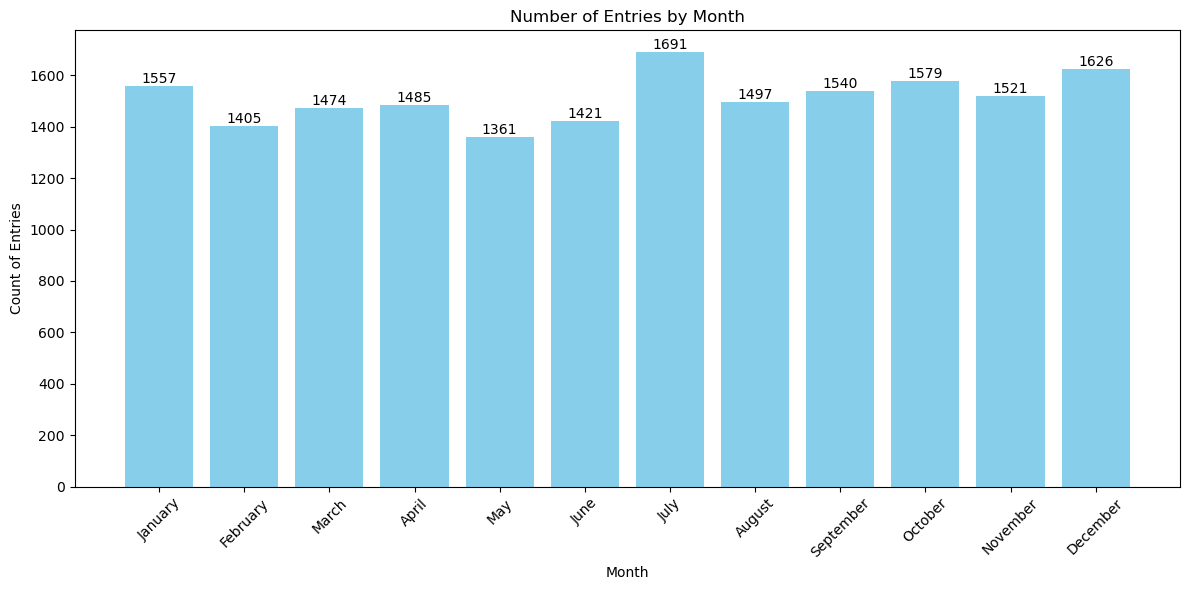

In [348]:
months = ['February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

monthly_counts = {}
for month in months:
    if month in df_dogs.columns:
        monthly_counts[month] = df_dogs[month].sum()

january_mask = ~df_dogs[months].any(axis=1)
monthly_counts['January'] = january_mask.sum()

ordered_months = ['January'] + months
monthly_true_counts = pd.Series({month: monthly_counts[month] for month in ordered_months if month in monthly_counts})

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_true_counts.index, monthly_true_counts.values, color='skyblue')
plt.title('Number of Entries by Month')
plt.xlabel('Month')
plt.ylabel('Count of Entries')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

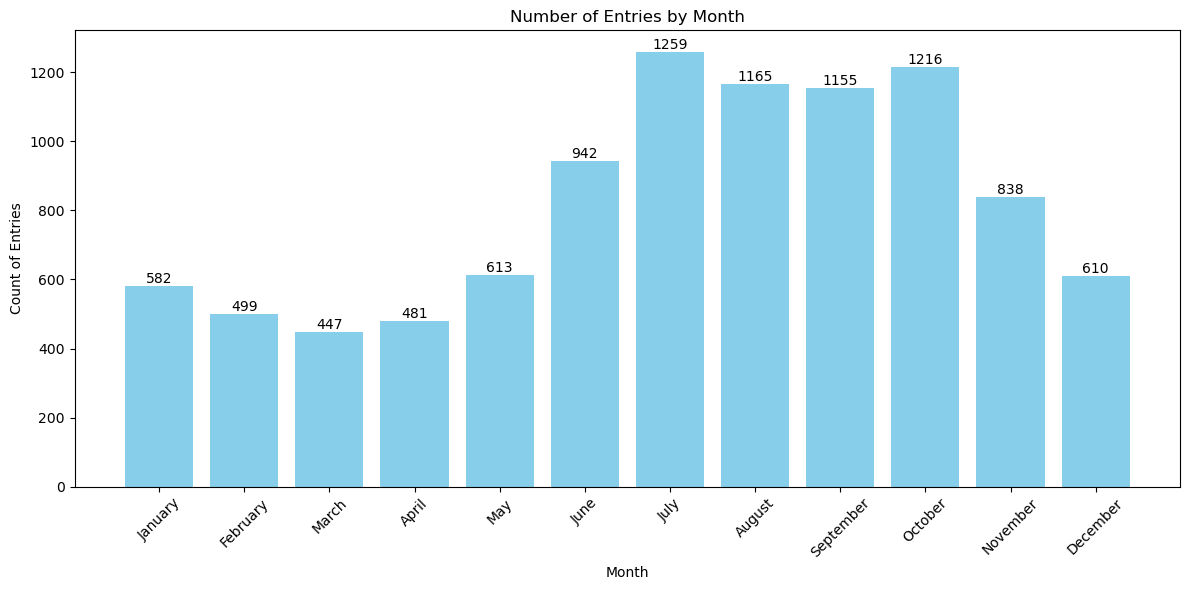

In [349]:
months = ['February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

monthly_counts = {}
for month in months:
    if month in df_cats.columns:
        monthly_counts[month] = df_cats[month].sum()
 
january_mask = ~df_cats[months].any(axis=1)
monthly_counts['January'] = january_mask.sum()

ordered_months = ['January'] + months
monthly_true_counts = pd.Series({month: monthly_counts[month] for month in ordered_months if month in monthly_counts})

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_true_counts.index, monthly_true_counts.values, color='skyblue')
plt.title('Number of Entries by Month')
plt.xlabel('Month')
plt.ylabel('Count of Entries')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

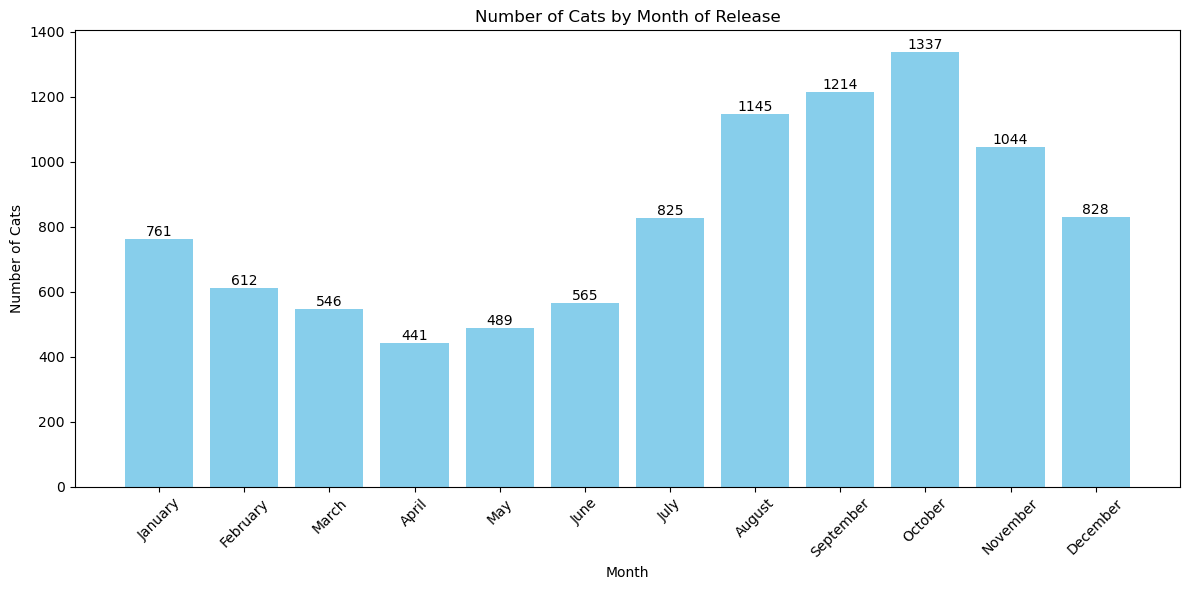

In [350]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

monthly_counts = df_cats['month_r'].value_counts().reindex(months, fill_value=0)

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_counts.index, monthly_counts.values, color='skyblue')
plt.title('Number of Cats by Month of Release')
plt.xlabel('Month')
plt.ylabel('Number of Cats')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

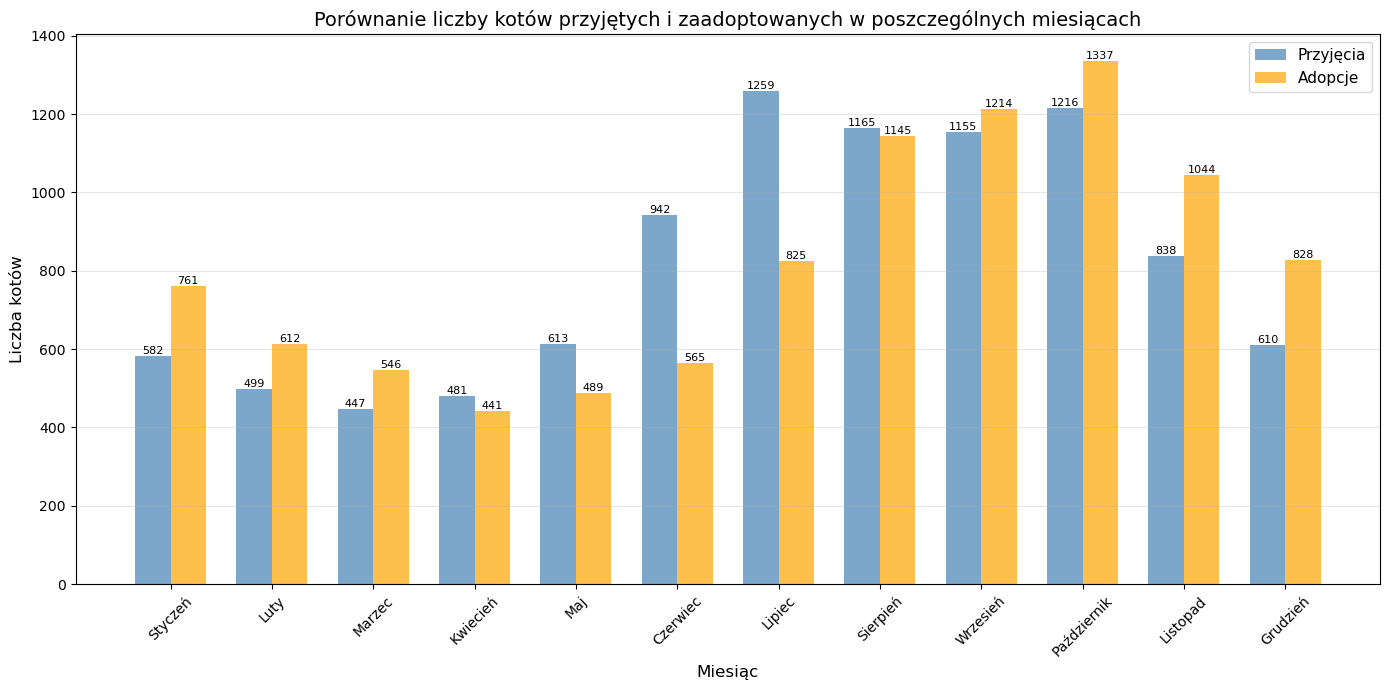

In [351]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

month_labels = ['Styczeń', 'Luty', 'Marzec', 'Kwiecień', 'Maj', 'Czerwiec', 
                'Lipiec', 'Sierpień', 'Wrzesień', 'Październik', 'Listopad', 'Grudzień']

existing_months = [month for month in months if month in df_cats.columns]

admission_counts = {}
for month in existing_months:
    admission_counts[month] = df_cats[month].sum()

january_mask = ~df_cats[existing_months].any(axis=1)
admission_counts['January'] = january_mask.sum()

admission_series = pd.Series({month: admission_counts.get(month, 0) for month in months})

release_counts = df_cats['month_r'].value_counts().reindex(months, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 7))

bar_width = 0.35
x = np.arange(len(months))

bars1 = ax.bar(x - bar_width/2, admission_series.values, 
               bar_width, label='Przyjęcia', color='steelblue', alpha=0.7)
bars2 = ax.bar(x + bar_width/2, release_counts.values, 
               bar_width, label='Adopcje', color='orange', alpha=0.7)

ax.set_xlabel('Miesiąc', fontsize=12)
ax.set_ylabel('Liczba kotów', fontsize=12)
ax.set_title('Porównanie liczby kotów przyjętych i zaadoptowanych w poszczególnych miesiącach', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(month_labels, rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [352]:
df_cats = df_cats.drop(columns=['month_r'])

# Logical regression

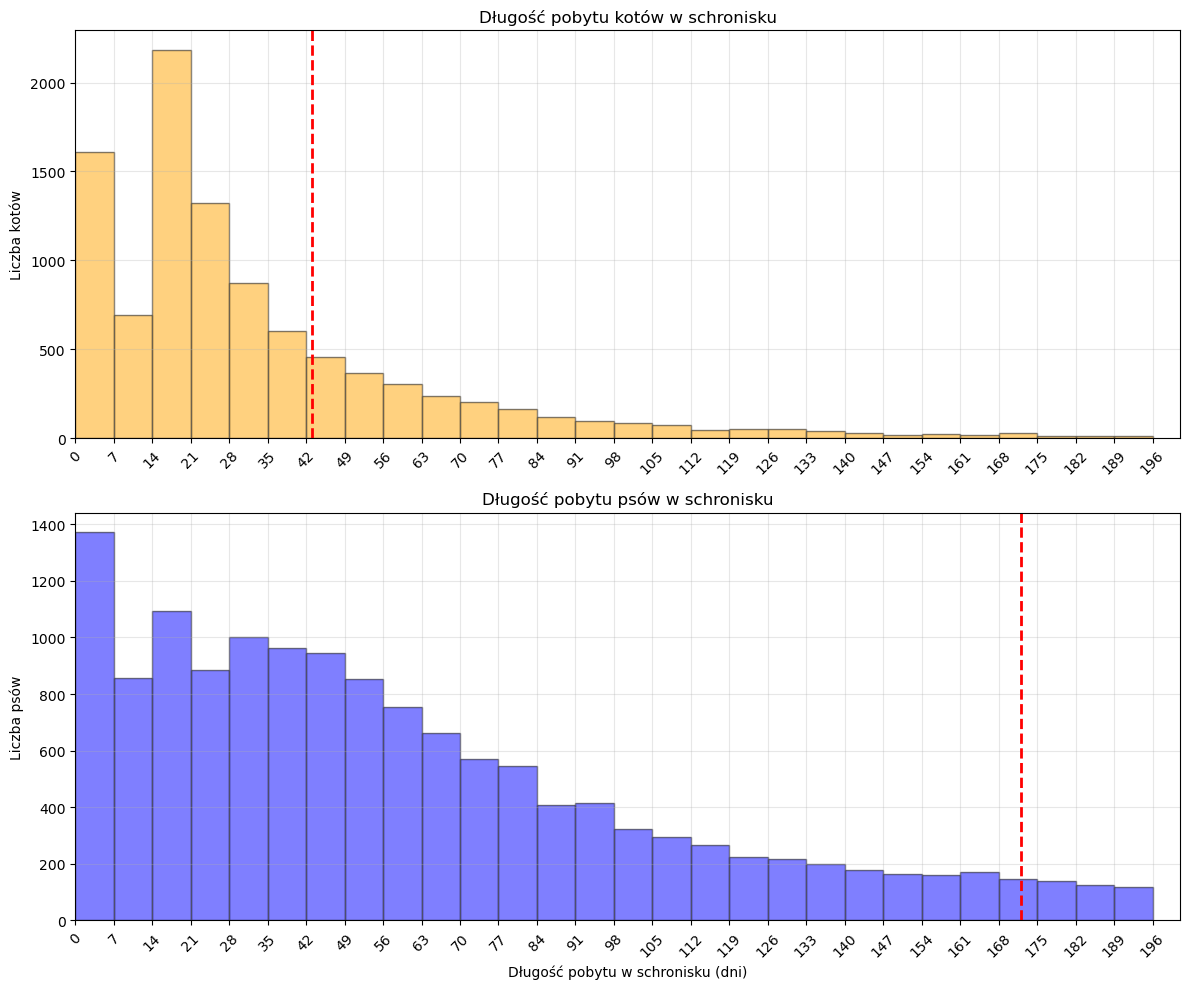

In [353]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

bin_edges = np.arange(0, 201, 7)

# Top plot - cats
ax1.hist(df_cats['stay_length'].dropna(), bins=bin_edges, alpha=0.5, color='orange', 
         label='Koty', edgecolor='black')

percentile_75_cats = np.percentile(df_cats['stay_length'].dropna(), 75)
ax1.axvline(x=percentile_75_cats, color='red', linestyle='--', linewidth=2, 
            label='')

ax1.set_title('Długość pobytu kotów w schronisku')
ax1.set_ylabel('Liczba kotów')
ax1.set_xlim(0, 201)
ax1.set_xticks(bin_edges)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Bottom plot - dogs
ax2.hist(df_dogs['stay_length'].dropna(), bins=bin_edges, alpha=0.5, color='blue', 
         label='Psy', edgecolor='black')

percentile_75_dogs = np.percentile(df_dogs['stay_length'].dropna(), 75)
ax2.axvline(x=percentile_75_dogs, color='red', linestyle='--', linewidth=2, 
            label='')

ax2.set_title('Długość pobytu psów w schronisku')
ax2.set_xlabel('Długość pobytu w schronisku (dni)')
ax2.set_ylabel('Liczba psów')
ax2.set_xlim(0, 201)
ax2.set_xticks(bin_edges)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [354]:
df_dogs_lr = df_dogs.copy()
df_cats_lr = df_cats.copy()

In [355]:
# Binary conversion of the independant variable
df_dogs = df_dogs.copy()
df_cats = df_cats.copy()

df_dogs['long_stay'] = (df_dogs['stay_length'] > 172).astype(int)
df_cats['long_stay'] = (df_cats['stay_length'] > 43).astype(int)

df_dogs = df_dogs.drop('stay_length', axis=1)
df_cats = df_cats.drop('stay_length', axis=1)

In [356]:
cols = ['long_stay', 'gender', 'weight', 'adult', 'senior', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
] + [col for col in df_dogs.columns if col not in ['long_stay', 'gender', 'weight', 'adult', 'senior', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
]]
df_dogs = df_dogs[cols]

In [357]:
cols = ['long_stay', 'gender', 'weight', 'adult', 'senior', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
] + [col for col in df_cats.columns if col not in ['long_stay', 'gender', 'weight', 'adult', 'senior', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
]]
df_cats = df_cats[cols]

In [358]:
# Code helping with identifying troublesome breeds

'''
y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:]
for col in X.columns:
    if col == 'const':
        continue
    
    print(f"\n--- {col} ---")
    
    crosstab = pd.crosstab(
        pd.cut(df_dogs[col], bins=5) if df_dogs[col].dtype in ['float64', 'int64'] else df_dogs[col], 
        y,
        margins=True)
    
    print(crosstab)
    
    unique_vals = df_dogs[col].nunique()
    print(f"Unique values: {unique_vals}")
    
    if unique_vals <= 10:
        for val in df_dogs[col].unique():
            subset = df_dogs[df_dogs[col] == val]
            prop_positive = subset.iloc[:, 0].mean()
            if prop_positive == 0 or prop_positive == 1:
                print("⚠️")
'''

problematic_dogs = ['akita inu', 'anatolian', 'berneński pies pasterski', 'biszon', 'cavalier king charles spaniel', 'chin japoński', 'dalmatyńczyk', 'dog niemiecki', 'dog z bordeaux', 'flat coate', 'fokster kr', 'grzywacz', 'grzywacz chiński', 'jugosłowiański pies pasterski', 'komondor', 'leonberger', 'lhasa apso', 'mastif', 'mix bulter', 'molos', 'nowofundland', 'ogar polski', 'old englis', 'owczarek francuski briard', 'owczarek h', 'owczarek s', 'owczarek szwacjarski', 'pointer', 'pomeranian', 'pon', 'posokowiec', 'rhodesian ridgeback', 'samojed', 'seter irlandzki', 'shar pei', 'shiba inu', 'spaniel tybetański', 'springer spaniel', 'szpic', 'toller', 'tosa inu', 'wilczak', 'wilczarz irlandzki', 'łajka', 'chihuahua', 'shih tzu']


In [359]:
'''
y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:]
for col in X.columns:
    if col == 'const':
        continue
    
    print(f"\n--- {col} ---")
    
    crosstab = pd.crosstab(
        pd.cut(df_cats[col], bins=5) if df_cats[col].dtype in ['float64', 'int64'] else df_cats[col], 
        y,
        margins=True)
    
    print(crosstab)
    
    unique_vals = df_cats[col].nunique()
    print(f"Unique values: {unique_vals}")
    
    if unique_vals <= 10:
        for val in df_cats[col].unique():
            subset = df_cats[df_cats[col] == val]
            if len(subset) > 0:
                prop_positive = subset.iloc[:, 0].mean()
                if prop_positive == 0 or prop_positive == 1:
                    print("⚠️")
'''

problematic_cats = ['abisyński', 'burmański', 'chausie', 'mix półdłu', 'dalekowschodni', 'devon rex', 'egzotyk', 'mieszaniec', 'mix ragdol', 'orientalny', 'ragdoll', 'sfinks', 'snowshoe', 'szkocki kr', 'szkocki zwisłouchy', 'tonkijski']


In [360]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:]

X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[3802  304]
 [1003  339]]

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85      4106
           1       0.53      0.25      0.34      1342

    accuracy                           0.76      5448
   macro avg       0.66      0.59      0.60      5448
weighted avg       0.73      0.76      0.73      5448


ROC AUC: 0.7828261756449614


In [361]:
y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()

X = X.drop(problematic_dogs, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit(maxiter=500, method='bfgs', disp=True)

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Logistic Regression Results (Training Data)")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Optimization terminated successfully.
         Current function value: 0.467999
         Iterations: 267
         Function evaluations: 268
         Gradient evaluations: 268
Logistic Regression Results (Training Data)<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: long_stay</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>-0.467<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.040)</td></tr>
<tr><td style="text-align:left">weight</td><td>0.802<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.024)</td></tr>
<tr><td style="text-align:left">adult</td><td>0.897<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.052)</td></tr>
<tr><td style="text-align:left">senior</td><td>1.297<sup>

In [362]:
print(f"Mean weight: {scaler.mean_[0]:.2f} kg")
print(f"Std weight: {scaler.scale_[0]:.2f} kg")

Mean weight: 14.49 kg
Std weight: 9.60 kg


In [363]:
y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()

X = X.drop(problematic_dogs, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

# INTERACTIONS
X['weight_adult'] = X['weight'] * X['adult']
X['weight_senior'] = X['weight'] * X['senior']
X['weight_gender'] = X['weight'] * X['gender']
X['adult_gender'] = X['adult'] * X['gender']
X['senior_gender'] = X['senior'] * X['gender']

X = X.astype(float)

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit(maxiter=500, method='bfgs', disp=True)

p_values = result.pvalues
insignificant_vars = p_values[(p_values > 0.1) & (p_values.index != 'const')].index.tolist()
insignificant_vars = [var for var in insignificant_vars]

X_reduced = X.drop(insignificant_vars, axis=1)

model2 = sm.Logit(y, X_reduced)
result2 = model2.fit(maxiter=500, method='bfgs', disp=True)

p_values = result2.pvalues
insignificant_vars = p_values[(p_values > 0.01) & (p_values.index != 'const')].index.tolist()
insignificant_vars = [var for var in insignificant_vars ]

X_reduced = X_reduced.drop(insignificant_vars, axis=1)

model3 = sm.Logit(y, X_reduced)
result3 = model3.fit(maxiter=500, method='bfgs', disp=True)

stargazer = Stargazer([result, result2, result3])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Logistic Regression Results with Interaction Terms (Training Data)")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Optimization terminated successfully.
         Current function value: 0.463553
         Iterations: 316
         Function evaluations: 317
         Gradient evaluations: 317
Optimization terminated successfully.
         Current function value: 0.464399
         Iterations: 153
         Function evaluations: 154
         Gradient evaluations: 154
Optimization terminated successfully.
         Current function value: 0.465541
         Iterations: 138
         Function evaluations: 139
         Gradient evaluations: 139
Logistic Regression Results with Interaction Terms (Training Data)<br><table style="text-align:center"><tr><td colspan="4" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="3"><em>Dependent variable: long_stay</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="4" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>-0.364<sup>***</sup></td><td>-0.465<sup>***</

In [364]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:]

X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[2181   53]
 [ 639   70]]

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86      2234
           1       0.57      0.10      0.17       709

    accuracy                           0.76      2943
   macro avg       0.67      0.54      0.52      2943
weighted avg       0.72      0.76      0.70      2943


ROC AUC: 0.6829458313814076


In [365]:
print(f"Mean weight: {scaler.mean_[0]:.2f} kg")
print(f"Std weight: {scaler.scale_[0]:.2f} kg")

Mean weight: 2.54 kg
Std weight: 1.47 kg


In [366]:
variables_without_const = [col for col in X.columns if col != 'const']

for i, col in enumerate(variables_without_const, 1):
    print(f"{i:3d}. {col}")

print(f"\nRazem: {len(variables_without_const)} zmienne (bez stałej)")

  1. gender
  2. weight
  3. adult
  4. senior
  5. February
  6. March
  7. April
  8. May
  9. June
 10. July
 11. August
 12. September
 13. October
 14. November
 15. December
 16. brytyjski
 17. maine coon
 18. norweski leśny
 19. perski
 20. rosyjski niebieski
 21. syberyjski
 22. syjamski
 23. black
 24. black patterned
 25. gradient
 26. grey
 27. multicolor
 28. no photo
 29. orange
 30. orange patterned
 31. white

Razem: 31 zmienne (bez stałej)


In [367]:
coeffs = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)
print(coeffs)

               feature      coef
8                 June  1.020947
9                 July  1.004681
10              August  0.894422
7                  May  0.750894
3               senior  0.708168
16          maine coon  0.707206
12             October  0.567510
11           September  0.541072
13            November  0.523130
2                adult  0.421325
23     black patterned  0.350183
1               weight  0.249930
6                April  0.248071
0               gender  0.005649
22               black -0.011081
17      norweski leśny -0.088344
14            December -0.107785
5                March -0.182958
4             February -0.204731
29    orange patterned -0.288573
28              orange -0.302349
24            gradient -0.327975
30               white -0.376407
18              perski -0.417800
19  rosyjski niebieski -0.494307
27            no photo -0.498961
26          multicolor -0.616656
21            syjamski -0.643706
25                grey -0.918219
15        

In [368]:
y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:].copy()

X = X.drop(problematic_cats, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit(maxiter=500, method='bfgs', disp=True)

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Logistic Regression Results (Training Data)")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Optimization terminated successfully.
         Current function value: 0.516528
         Iterations: 228
         Function evaluations: 229
         Gradient evaluations: 229
Logistic Regression Results (Training Data)<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: long_stay</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>-0.004<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.052)</td></tr>
<tr><td style="text-align:left">weight</td><td>0.237<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.037)</td></tr>
<tr><td style="text-align:left">adult</td><td>0.459<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.076)</td></tr>
<tr><td style="text-align:left">senior</td><td>0.841<sup>***

# Random forest

In [369]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()
X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

feature_cols = X.columns.tolist()

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

rf_model = grid_search.best_estimator_

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

results_df = pd.DataFrame(grid_search.cv_results_)

comparison_table = pd.DataFrame({
    'n_estimators': results_df['param_n_estimators'],
    'max_depth': results_df['param_max_depth'],
    'min_samples_split': results_df['param_min_samples_split'],
    'min_samples_leaf': results_df['param_min_samples_leaf'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 200}
Best cross-validation score: 0.782

Top 10 Most Important Features:
               feature  importance
1               weight    0.621755
2                adult    0.095400
3               senior    0.087163
0               gender    0.065279
15             amstaff    0.016434
51             terrier    0.012496
41  owczarek niemiecki    0.010008
12             October    0.005068
24      cocker spaniel    0.004930
10              August    0.004880


In [370]:
feature_importance_display = feature_importance.head(60).copy()
feature_importance_display['importance'] = feature_importance_display['importance'].apply(lambda x: f'{x:.6f}')

html_table = feature_importance_display.to_html(index=False)
display(HTML(html_table))

feature,importance
weight,0.621755
adult,0.095400
senior,0.087163
gender,0.065279
amstaff,0.016434
terrier,0.012496
owczarek niemiecki,0.010008
October,0.005068
cocker spaniel,0.004930
August,0.004880


In [371]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:]

X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[2650 1456]
 [ 276 1066]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.75      4106
           1       0.42      0.79      0.55      1342

    accuracy                           0.68      5448
   macro avg       0.66      0.72      0.65      5448
weighted avg       0.79      0.68      0.70      5448


ROC AUC: 0.7854131716661961


In [372]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:].copy()

X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

feature_cols = X.columns.tolist()

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

rf_model = grid_search.best_estimator_

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

rf_model = grid_search.best_estimator_

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

results_df = pd.DataFrame(grid_search.cv_results_)

comparison_table = pd.DataFrame({
    'n_estimators': results_df['param_n_estimators'],
    'max_depth': results_df['param_max_depth'],
    'min_samples_split': results_df['param_min_samples_split'],
    'min_samples_leaf': results_df['param_min_samples_leaf'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.675

Top 10 Most Important Features:
            feature  importance
1            weight    0.265842
23  black patterned    0.095484
3            senior    0.081210
2             adult    0.071221
27         no photo    0.064765
9              July    0.055470
8              June    0.052989
4          February    0.041146
14         December    0.037281
10           August    0.033360

Top 10 Most Important Features:
            feature  importance
1            weight    0.265842
23  black patterned    0.095484
3            senior    0.081210
2             adult    0.071221
27         no photo    0.064765
9              July    0.055470
8              June    0.052989
4          February    0.041146
14         December    0.037281
10           August    0.033360


In [373]:
html_table = feature_importance.head(60).to_html(index=False)
display(HTML(html_table))

feature,importance
weight,0.265842
black patterned,0.095484
senior,0.081210
adult,0.071221
no photo,0.064765
July,0.055470
June,0.052989
February,0.041146
December,0.037281
August,0.033360


In [374]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:]

X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[1421  813]
 [ 284  425]]

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.64      0.72      2234
           1       0.34      0.60      0.44       709

    accuracy                           0.63      2943
   macro avg       0.59      0.62      0.58      2943
weighted avg       0.72      0.63      0.65      2943


ROC AUC: 0.6779224903498061


# Gradient Boosting

In [375]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()

X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_gb.best_params_}")
print(f"Best cross-validation score: {grid_search_gb.best_score_:.3f}")

results_df = pd.DataFrame(grid_search_gb.cv_results_)

comparison_table = pd.DataFrame({
    'n_estimators': results_df['param_n_estimators'],
    'learning_rate': results_df['param_learning_rate'],
    'max_depth': results_df['param_max_depth'],
    'min_samples_split': results_df['param_min_samples_split'],
    'min_samples_leaf': results_df['param_min_samples_leaf'],
    'subsample': results_df['param_subsample'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation score: 0.786


In [376]:
html_table = comparison_table.drop(columns=['Std_CV_AUC', 'Rank']).head(10).to_html(index=False)
display(HTML(html_table))

n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,Mean_CV_AUC
200,0.05,3,20,5,0.8,0.786210
200,0.05,3,10,5,0.8,0.786167
200,0.05,3,5,5,0.8,0.786167
50,0.20,3,10,2,0.9,0.786078
200,0.05,3,10,5,1.0,0.786050
200,0.05,3,5,5,1.0,0.786050
100,0.10,3,10,5,1.0,0.786044
100,0.10,3,5,5,1.0,0.786044
200,0.05,3,20,5,1.0,0.786002
50,0.20,3,20,5,0.9,0.785909


In [377]:
feature_importance_gb = pd.DataFrame({
    'feature': X.columns,
    'importance': grid_search_gb.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

In [378]:
html_table = feature_importance_gb.head(60).to_html(index=False)
display(HTML(html_table))

feature,importance
weight,0.755911
senior,0.057775
gender,0.045208
adult,0.026811
owczarek niemiecki,0.014125
labrador,0.013613
amstaff,0.008516
malamut,0.007735
bokser,0.007158
cocker spaniel,0.005998


In [379]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:]
X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[3765  323]
 [ 909  451]]

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      4088
           1       0.58      0.33      0.42      1360

    accuracy                           0.77      5448
   macro avg       0.69      0.63      0.64      5448
weighted avg       0.75      0.77      0.75      5448


ROC AUC: 0.8009055377287903


In [380]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:].copy()

X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_gb.best_params_}")
print(f"Best cross-validation score: {grid_search_gb.best_score_:.3f}")

results_df = pd.DataFrame(grid_search_gb.cv_results_)

comparison_table = pd.DataFrame({
    'n_estimators': results_df['param_n_estimators'],
    'learning_rate': results_df['param_learning_rate'],
    'max_depth': results_df['param_max_depth'],
    'min_samples_split': results_df['param_min_samples_split'],
    'min_samples_leaf': results_df['param_min_samples_leaf'],
    'subsample': results_df['param_subsample'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.679


In [381]:
html_table = comparison_table.drop(columns=['Std_CV_AUC', 'Rank']).head(10).to_html(index=False)
display(HTML(html_table))

n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,Mean_CV_AUC
100,0.10,3,10,10,0.8,0.679119
100,0.10,3,20,10,0.8,0.679119
100,0.10,3,5,10,0.8,0.679119
100,0.10,3,10,2,0.8,0.678736
100,0.10,3,20,2,0.8,0.678595
200,0.05,3,10,2,0.8,0.678531
200,0.05,3,10,10,0.8,0.678528
200,0.05,3,5,10,0.8,0.678528
200,0.05,3,20,10,0.8,0.678528
50,0.20,3,5,10,0.8,0.678516


In [382]:
feature_importance_gb = pd.DataFrame({
    'feature': X.columns,
    'importance': grid_search_gb.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

In [383]:
html_table = feature_importance_gb.head(60).to_html(index=False)
display(HTML(html_table))

feature,importance
weight,0.261629
black patterned,0.099921
June,0.077474
July,0.075433
senior,0.065364
no photo,0.061851
August,0.045208
December,0.035602
adult,0.032930
February,0.032826


In [384]:
html_table = comparison_table.drop(columns=['Std_CV_AUC', 'Rank']).head(10).to_html(index=False)
display(HTML(html_table))

n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,Mean_CV_AUC
100,0.10,3,10,10,0.8,0.679119
100,0.10,3,20,10,0.8,0.679119
100,0.10,3,5,10,0.8,0.679119
100,0.10,3,10,2,0.8,0.678736
100,0.10,3,20,2,0.8,0.678595
200,0.05,3,10,2,0.8,0.678531
200,0.05,3,10,10,0.8,0.678528
200,0.05,3,5,10,0.8,0.678528
200,0.05,3,20,10,0.8,0.678528
50,0.20,3,5,10,0.8,0.678516


In [385]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:]
X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=10,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[2172   58]
 [ 656   57]]

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86      2230
           1       0.50      0.08      0.14       713

    accuracy                           0.76      2943
   macro avg       0.63      0.53      0.50      2943
weighted avg       0.70      0.76      0.68      2943


ROC AUC: 0.6737359983396122


# SVM

In [386]:
# Model - dogs

y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()

X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linearsvc', LinearSVC(random_state=42, max_iter=10000, dual='auto'))
])

param_grid_svm = {
    'linearsvc__C': [0.01, 0.1, 1, 10, 100],
    'linearsvc__loss': ['hinge', 'squared_hinge'],
    'linearsvc__class_weight': [None, 'balanced']
}

grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation score: {grid_search_svm.best_score_:.3f}")

results_df = pd.DataFrame(grid_search_svm.cv_results_)

comparison_table = pd.DataFrame({
    'C': results_df['param_linearsvc__C'],
    'Loss': results_df['param_linearsvc__loss'],
    'Class_Weight': results_df['param_linearsvc__class_weight'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'linearsvc__C': 0.1, 'linearsvc__class_weight': 'balanced', 'linearsvc__loss': 'hinge'}
Best cross-validation score: 0.776


In [387]:
html_table = comparison_table.drop(columns=['Std_CV_AUC', 'Rank']).head(10).to_html(index=False)
display(HTML(html_table))

C,Loss,Class_Weight,Mean_CV_AUC
0.10,hinge,balanced,0.776227
0.01,squared_hinge,NaN,0.775931
0.10,squared_hinge,NaN,0.775880
1.00,squared_hinge,NaN,0.775871
10.00,squared_hinge,NaN,0.775870
100.00,squared_hinge,NaN,0.775870
1.00,hinge,balanced,0.775734
0.01,hinge,balanced,0.775336
0.01,squared_hinge,balanced,0.774151
0.10,squared_hinge,balanced,0.774117


In [388]:
feature_importance_svm = pd.DataFrame({
    'feature': X.columns,
    'coefficient': grid_search_svm.best_estimator_.named_steps['linearsvc'].coef_[0]
})
feature_importance_svm['abs_importance'] = feature_importance_svm['coefficient'].abs()
feature_importance_svm = feature_importance_svm.sort_values('abs_importance', ascending=False)

feature_importance_svm['coefficient'] = feature_importance_svm['coefficient'].apply(lambda x: f'{x:.6f}')
feature_importance_svm['abs_importance'] = feature_importance_svm['abs_importance'].apply(lambda x: f'{x:.6f}')

html_table = feature_importance_svm.head(60).to_html(index=False)
display(HTML(html_table))

feature,coefficient,abs_importance
weight,0.868485,0.868485
senior,0.386102,0.386102
adult,0.318180,0.318180
gender,-0.224566,0.224566
labrador,-0.183963,0.183963
owczarek niemiecki,-0.163260,0.163260
rottweiler,-0.141736,0.141736
malamut,-0.122936,0.122936
terrier,-0.120403,0.120403
bokser,-0.106561,0.106561


In [389]:
y = df_dogs.iloc[:, 0]
X = df_dogs.iloc[:, 1:].copy()
X = X.drop(problematic_dogs, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

model = LinearSVC(
    C=0.1,
    class_weight='balanced',
    loss='hinge',
    random_state=42,
    max_iter=10000,
    dual='auto'
)

model.fit(X_train_scaled_df, y_train)

y_pred = model.predict(X_test_scaled_df)
y_pred_proba = model.decision_function(X_test_scaled_df)  # For AUC

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_pred_proba))

Confusion matrix:
[[2791 1297]
 [ 309 1051]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      4088
           1       0.45      0.77      0.57      1360

    accuracy                           0.71      5448
   macro avg       0.67      0.73      0.67      5448
weighted avg       0.79      0.71      0.72      5448


ROC AUC: 0.7927711666858525


In [390]:
# Model - cats

y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:].copy()

X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('linearsvc', LinearSVC(random_state=42, max_iter=10000, dual='auto'))
])

param_grid_svm = {
    'linearsvc__C': [0.01, 0.1, 1, 10, 100],
    'linearsvc__loss': ['hinge', 'squared_hinge'],
    'linearsvc__class_weight': [None, 'balanced']
}

grid_search_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_svm.best_params_}")
print(f"Best cross-validation score: {grid_search_svm.best_score_:.3f}")

results_df = pd.DataFrame(grid_search_svm.cv_results_)

comparison_table = pd.DataFrame({
    'C': results_df['param_linearsvc__C'],
    'Loss': results_df['param_linearsvc__loss'],
    'Class_Weight': results_df['param_linearsvc__class_weight'],
    'Mean_CV_AUC': results_df['mean_test_score'],
    'Std_CV_AUC': results_df['std_test_score'],
    'Rank': results_df['rank_test_score']
})

comparison_table = comparison_table.sort_values('Mean_CV_AUC', ascending=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'linearsvc__C': 0.1, 'linearsvc__class_weight': 'balanced', 'linearsvc__loss': 'squared_hinge'}
Best cross-validation score: 0.672


In [391]:
html_table = comparison_table.drop(columns=['Std_CV_AUC', 'Rank']).head(10).to_html(index=False)
display(HTML(html_table))

C,Loss,Class_Weight,Mean_CV_AUC
0.10,squared_hinge,balanced,0.672164
10.00,squared_hinge,balanced,0.672149
100.00,squared_hinge,balanced,0.672146
1.00,squared_hinge,balanced,0.672145
0.01,squared_hinge,balanced,0.672022
0.10,squared_hinge,NaN,0.671905
1.00,squared_hinge,NaN,0.671865
10.00,squared_hinge,NaN,0.671862
100.00,squared_hinge,NaN,0.671858
0.01,squared_hinge,NaN,0.671664


In [392]:
feature_importance_svm = pd.DataFrame({
    'feature': X.columns,
    'coefficient': grid_search_svm.best_estimator_.named_steps['linearsvc'].coef_[0]
})
feature_importance_svm['abs_importance'] = feature_importance_svm['coefficient'].abs()
feature_importance_svm = feature_importance_svm.sort_values('abs_importance', ascending=False)

feature_importance_svm['coefficient'] = feature_importance_svm['coefficient'].apply(lambda x: f'{x:.6f}')
feature_importance_svm['abs_importance'] = feature_importance_svm['abs_importance'].apply(lambda x: f'{x:.6f}')

html_table = feature_importance_svm.head(60).to_html(index=False)
display(HTML(html_table))

feature,coefficient,abs_importance
July,0.164437,0.164437
August,0.137250,0.137250
June,0.126196,0.126196
weight,0.118209,0.118209
senior,0.107314,0.107314
no photo,-0.098625,0.098625
adult,0.098541,0.098541
September,0.080440,0.080440
October,0.076715,0.076715
May,0.076231,0.076231


In [393]:
y = df_cats.iloc[:, 0]
X = df_cats.iloc[:, 1:].copy()
X = X.drop(problematic_cats, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

model = LinearSVC(
    C=0.1,
    class_weight='balanced',
    loss='squared_hinge',
    random_state=42,
    max_iter=10000,
    dual='auto'
)

model.fit(X_train_scaled_df, y_train)

y_pred = model.predict(X_test_scaled_df)
y_pred_proba = model.decision_function(X_test_scaled_df)  # For AUC

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_pred_proba))

Confusion matrix:
[[1456  774]
 [ 298  415]]

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.65      0.73      2230
           1       0.35      0.58      0.44       713

    accuracy                           0.64      2943
   macro avg       0.59      0.62      0.58      2943
weighted avg       0.71      0.64      0.66      2943


ROC AUC: 0.6647032371272775


# Extras

In [394]:
# Model - cats excluding "no photo"

df_cats_with_photos = df_cats[df_cats['no photo'] == 0].copy()

y = df_cats_with_photos.iloc[:, 0]
X = df_cats_with_photos.iloc[:, 1:]

X = X.drop(problematic_cats, axis=1)
X = X.drop('no photo', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['weight'] = scaler.fit_transform(X_train[['weight']])
X_test_scaled['weight'] = scaler.transform(X_test[['weight']])

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
[[1329   55]
 [ 463   65]]

Classification report:
              precision    recall  f1-score   support

           0       0.74      0.96      0.84      1384
           1       0.54      0.12      0.20       528

    accuracy                           0.73      1912
   macro avg       0.64      0.54      0.52      1912
weighted avg       0.69      0.73      0.66      1912


ROC AUC: 0.6722889571290944


In [395]:
coeffs = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)
print(coeffs)

               feature      coef
16          maine coon  1.328467
9                 July  1.112944
8                 June  1.079835
3               senior  0.998130
10              August  0.977789
11           September  0.708693
7                  May  0.698247
12             October  0.614955
13            November  0.476843
23     black patterned  0.378933
1               weight  0.302398
2                adult  0.249783
6                April  0.194130
0               gender  0.020368
22               black  0.019994
29               white -0.072677
21            syjamski -0.143216
24            gradient -0.216023
28    orange patterned -0.229777
27              orange -0.239789
5                March -0.319730
15           brytyjski -0.347357
14            December -0.375344
18              perski -0.422869
25                grey -0.456843
19  rosyjski niebieski -0.540785
4             February -0.547426
26          multicolor -0.597993
17      norweski leśny -0.643473
20        

In [396]:
df_cats_with_photos = df_cats[df_cats['no photo'] == 0].copy()

y = df_cats_with_photos.iloc[:, 0]
X = df_cats_with_photos.iloc[:, 1:]

X = X.drop(problematic_cats, axis=1)
X = X.drop('no photo', axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit(maxiter=500, method='bfgs', disp=True)

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Logistic Regression Results (Training Data)")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Optimization terminated successfully.
         Current function value: 0.536164
         Iterations: 198
         Function evaluations: 199
         Gradient evaluations: 199
Logistic Regression Results (Training Data)<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: long_stay</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>-0.009<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.064)</td></tr>
<tr><td style="text-align:left">weight</td><td>0.308<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.046)</td></tr>
<tr><td style="text-align:left">adult</td><td>0.269<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.095)</td></tr>
<tr><td style="text-align:left">senior</td><td>0.957<sup>***

In [397]:
X = df_cats.iloc[:, 1:].copy()
X = X.drop(problematic_cats, axis=1)
for i, col in enumerate(X.columns):
    print(f"{i}: {col}")

0: gender
1: weight
2: adult
3: senior
4: February
5: March
6: April
7: May
8: June
9: July
10: August
11: September
12: October
13: November
14: December
15: brytyjski
16: maine coon
17: norweski leśny
18: perski
19: rosyjski niebieski
20: syberyjski
21: syjamski
22: black
23: black patterned
24: gradient
25: grey
26: multicolor
27: no photo
28: orange
29: orange patterned
30: white


In [398]:
X = df_dogs.iloc[:, 1:].copy()
X = X.drop(problematic_dogs, axis=1)
for i, col in enumerate(X.columns):
    print(f"{i}: {col}")

0: gender
1: weight
2: adult
3: senior
4: February
5: March
6: April
7: May
8: June
9: July
10: August
11: September
12: October
13: November
14: December
15: amstaff
16: beagle
17: bernardyn
18: bokser
19: border collie
20: buldog
21: cane corso
22: chart
23: chow chow
24: cocker spaniel
25: collie
26: doberman
27: dog argentyński
28: dog kanaryjski
29: golden retriever
30: gończy polski
31: husky
32: jamnik
33: karelski pies na niedźwiedzie
34: labrador
35: malamut
36: maltańczyk
37: mix ast
38: mops
39: owczarek belgijski
40: owczarek kaukaski
41: owczarek niemiecki
42: owczarek podhalański
43: owczarek środkowoazjatycki
44: pekińczyk
45: pinczer
46: pitbul
47: pudel
48: ratlerek
49: rottweiler
50: sznaucer
51: terrier
52: wyżeł


In [399]:
y = df_dogs_lr['stay_length']
X = df_dogs_lr.drop(columns=['stay_length'])

if y.dtype == 'object':
    y = pd.to_numeric(y)

X = X.drop(problematic_dogs, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Linear Regression Results - Stay Length")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Linear Regression Results - Stay Length<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: stay_length</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>-71.718<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(8.684)</td></tr>
<tr><td style="text-align:left">weight</td><td>185.780<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(5.393)</td></tr>
<tr><td style="text-align:left">April</td><td>3.286<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(20.676)</td></tr>
<tr><td style="text-align:left">August</td><td>-4.189<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(20.639)</td></tr>
<tr><td style="text-align:left">December</td><td>9.373<sup></sup></td></tr>
<tr><td style="text-al

In [400]:
y = df_cats_lr['stay_length']
X = df_cats_lr.drop(columns=['stay_length'])

if y.dtype == 'object':
    y = pd.to_numeric(y)

X = X.drop(problematic_cats, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Linear Regression Results - Stay Length")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Linear Regression Results - Stay Length<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: stay_length</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>1.850<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(1.172)</td></tr>
<tr><td style="text-align:left">weight</td><td>5.934<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.856)</td></tr>
<tr><td style="text-align:left">April</td><td>12.184<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(3.394)</td></tr>
<tr><td style="text-align:left">August</td><td>10.707<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(2.804)</td></tr>
<tr><td style="text-align:left">December</td><td>0.002<sup></sup></td></tr>
<tr><td style="text-alig

In [401]:
df_cats_lr_filtered = df_cats_lr[df_cats_lr['no photo'] == 0].copy()

y = df_cats_lr_filtered['stay_length']
X = df_cats_lr_filtered.drop(columns=['stay_length', 'no photo'])

if y.dtype == 'object':
    y = pd.to_numeric(y)

X = X.drop(problematic_cats, axis=1)

scaler = StandardScaler()
X['weight'] = scaler.fit_transform(X[['weight']])

X = X.astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X)
result = model.fit()

stargazer = Stargazer([result])

original_columns = [col for col in X.columns if col != 'const'] 
original_columns.append('const')

stargazer.covariate_order(original_columns)
stargazer.title("Linear Regression Results - Stay Length (Cats with Photos Only)")
stargazer.show_model_numbers(False)
stargazer.significance_levels([0.1, 0.05, 0.01])
stargazer.show_confidence_intervals(False)

html_output = stargazer.render_html()
print(html_output)

Linear Regression Results - Stay Length (Cats with Photos Only)<br><table style="text-align:center"><tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>
<tr><td style="text-align:left"></td><td colspan="1"><em>Dependent variable: stay_length</em></td></tr><tr><td style="text-align:left"></td>
<tr><td colspan="2" style="border-bottom: 1px solid black"></td></tr>

<tr><td style="text-align:left">gender</td><td>1.459<sup></sup></td></tr>
<tr><td style="text-align:left"></td><td>(1.106)</td></tr>
<tr><td style="text-align:left">weight</td><td>7.438<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(0.803)</td></tr>
<tr><td style="text-align:left">April</td><td>12.796<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(3.056)</td></tr>
<tr><td style="text-align:left">August</td><td>13.994<sup>***</sup></td></tr>
<tr><td style="text-align:left"></td><td>(2.625)</td></tr>
<tr><td style="text-align:left">December</td><td>1.023<sup></sup></td></tr>
